In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


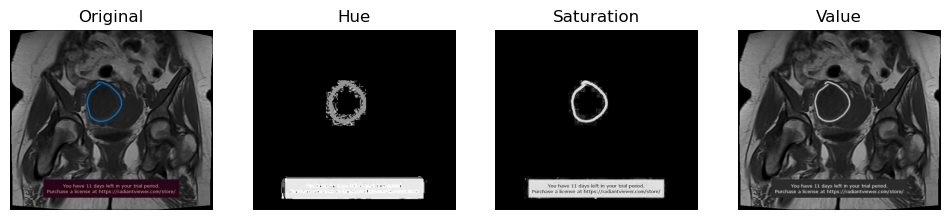

In [2]:

# Read image
img = cv2.imread(r"C:\Users\Admin\Desktop\coronal T1.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert RGB to HSV
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Split channels
H, S, V = cv2.split(hsv)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_rgb, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(H, cmap='gray')
plt.title("Hue")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.show()

In [3]:
# Function to do nothing (trackbar callback)
def nothing(x):
    pass

# Load image
img = cv2.imread(r"C:\Users\Admin\Desktop\coronal T1.jpg")

# Convert to HSV
hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Create window
cv2.namedWindow('Trackbars')

# Create trackbars
cv2.createTrackbar('H Min', 'Trackbars', 0, 179, nothing)
cv2.createTrackbar('H Max', 'Trackbars', 179, 179, nothing)
cv2.createTrackbar('S Min', 'Trackbars', 0, 255, nothing)
cv2.createTrackbar('S Max', 'Trackbars', 255, 255, nothing)
cv2.createTrackbar('V Min', 'Trackbars', 0, 255, nothing)
cv2.createTrackbar('V Max', 'Trackbars', 255, 255, nothing)

while True:
    # Get trackbar values
    h_min = cv2.getTrackbarPos('H Min', 'Trackbars')
    h_max = cv2.getTrackbarPos('H Max', 'Trackbars')
    s_min = cv2.getTrackbarPos('S Min', 'Trackbars')
    s_max = cv2.getTrackbarPos('S Max', 'Trackbars')
    v_min = cv2.getTrackbarPos('V Min', 'Trackbars')
    v_max = cv2.getTrackbarPos('V Max', 'Trackbars')

    # HSV range
    lower_hsv = np.array([h_min, s_min, v_min])
    upper_hsv = np.array([h_max, s_max, v_max])

    # Mask
    mask = cv2.inRange(hsv_image, lower_hsv, upper_hsv)

    # Result (original masked)
    result = cv2.bitwise_and(img, img, mask=mask)

    # ---- CONTOUR DETECTION ----
    # Find contours on the binary mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw all contours on the 'result' image (in green)
    contour_img = result.copy()
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

    # Optional: find and draw the largest contour
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(contour_img, [largest_contour], -1, (0, 0, 255), 3)  # red for largest

    # Show images
    cv2.imshow('Original Image', img)
    cv2.imshow('Mask', mask)
    cv2.imshow('Filtered Image', result)
    cv2.imshow('Contours', contour_img)   # new window with contours

    # Exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2570: error: (-27:Null pointer) NULL window: 'Trackbars' in function 'cvGetTrackbarPos'


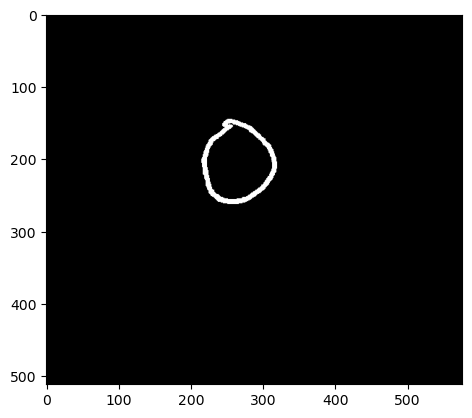

In [4]:
lower_blue = np.array([90, 100, 50])
upper_blue = np.array([130, 255, 255])

blue_outline = cv2.inRange(hsv, lower_blue, upper_blue)


plt.imshow(blue_outline, cmap='gray')

plt.show()

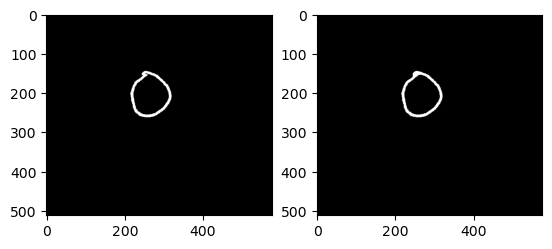

In [5]:
kernel = np.ones((5,5), np.uint8)

closed = cv2.morphologyEx(blue_outline, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.subplot(1,2,1); plt.imshow(blue_outline, cmap='gray')
plt.subplot(1,2,2); plt.imshow(closed, cmap='gray')
plt.show()

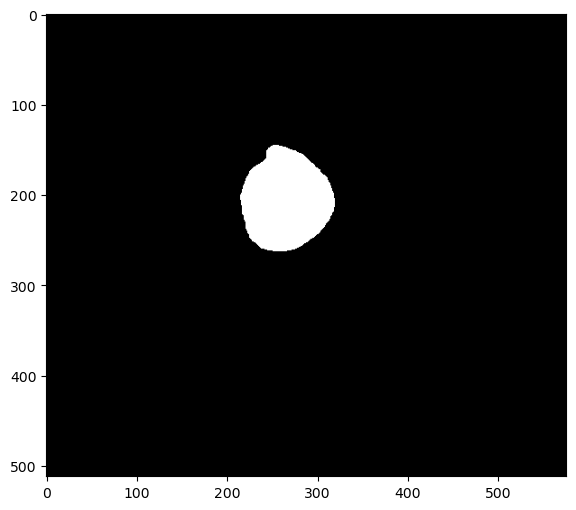

In [6]:
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

biggest = max(contours, key=cv2.contourArea)

tumor_mask = np.zeros(img.shape[:2], dtype=np.uint8)
cv2.drawContours(tumor_mask, [biggest], -1, color=255, thickness=cv2.FILLED)

plt.figure(figsize=(8,6))
plt.imshow(tumor_mask, cmap='gray')
plt.show()

In [7]:
cv2.imwrite(r"C:\Users\Admin\Desktop\tumor_mask.png", tumor_mask)

True